# Data Dictionary

In [67]:
# Basic liberaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn liberaries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

In [68]:
data = pd.read_csv('bank.csv')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [69]:
data.shape

(11162, 17)

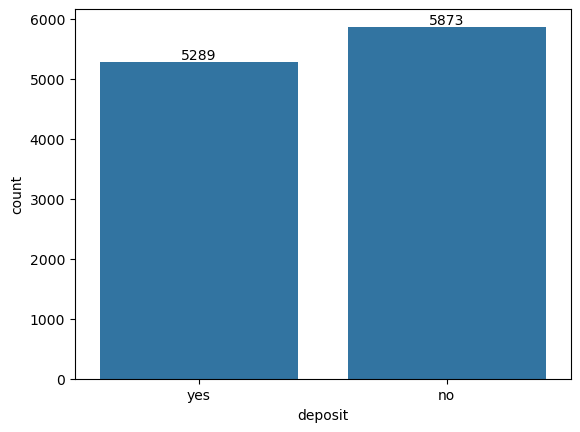

deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64

In [70]:
# Analysing the target column

ax = sns.countplot(x='deposit', data=data)
ax.bar_label(ax.containers[0])
plt.show()

# Proportion check
# to see the distribution of the data wheather it is normally distributed or not

round(data['deposit'].value_counts(normalize=True)*100,2)

In [71]:
# checking the null values

data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [72]:
data.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [73]:
# number of unique columns in categorical columns

for cols in data.columns:
    if data[cols].dtype =='O':
        print(cols, ':',data[cols].nunique())

job : 12
marital : 3
education : 4
default : 2
housing : 2
loan : 2
contact : 3
month : 12
poutcome : 4
deposit : 2


# Preparing the data for ML models

In [74]:
# dependency split

x = data.drop('deposit', axis=1)

# independent split

y = data[['deposit']]
print(x.shape, y.shape, sep='\n')

(11162, 16)
(11162, 1)


In [75]:
# train test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(x_train.shape,x_test.shape,y_train.shape, y_test.shape, sep='\n')

(7813, 16)
(3349, 16)
(7813, 1)
(3349, 1)


# Encoding

In [76]:
# List of categorical coluumns

cat_cols = [cols for cols in x_train.columns if x_train[cols].dtype =='O']

# Label encoder

encoders = {}

#Apply label encoder for train data

for col in cat_cols:
    encoders[col] = LabelEncoder()
    x_train[col] = encoders[col].fit_transform(x_train[col])

# Apply label encoder for test data

for col in cat_cols:
    x_test[col] = encoders[col].transform(x_test[col])

In [77]:
encoders = {}
for col in cat_cols:
    encoders[col] = LabelEncoder()
print(encoders)


{'job': LabelEncoder(), 'marital': LabelEncoder(), 'education': LabelEncoder(), 'default': LabelEncoder(), 'housing': LabelEncoder(), 'loan': LabelEncoder(), 'contact': LabelEncoder(), 'month': LabelEncoder(), 'poutcome': LabelEncoder()}


In [78]:
# data sample after encoding
x_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
7968,57,9,1,1,0,950,1,0,0,9,5,1272,1,-1,0,3
1456,34,9,2,2,0,925,1,0,0,13,0,709,1,-1,0,3
361,41,1,2,1,0,75,1,0,2,1,5,479,9,-1,0,3
812,46,9,2,2,0,4414,0,0,0,18,1,504,7,-1,0,3
1092,28,11,2,1,0,4465,0,0,0,28,4,769,1,-1,0,3


In [79]:
# Building a simple decision tree with random parameters values

model = DecisionTreeClassifier(max_depth=7,random_state=42)
model.fit(x_train, y_train)
train_score = model.score(x_train,y_train)
print('Training Score:', round(train_score*100,2),'%')

Training Score: 83.69 %


In [80]:
# test prediction

y_pred = model.predict(x_test)

# testing accuracy

test_score = accuracy_score(y_test, y_pred)
print('Test Score:', round(test_score*100,2),'%')
print('Precision Score:',round(precision_score(y_test, y_pred, pos_label='yes')*100,2),'%')
print('Recall_score:',round(recall_score(y_test, y_pred, pos_label='yes')*100,2),'%')

Test Score: 81.55 %
Precision Score: 83.85 %
Recall_score: 76.23 %


              precision    recall  f1-score   support

          no       0.80      0.86      0.83      1742
         yes       0.84      0.76      0.80      1607

    accuracy                           0.82      3349
   macro avg       0.82      0.81      0.81      3349
weighted avg       0.82      0.82      0.81      3349



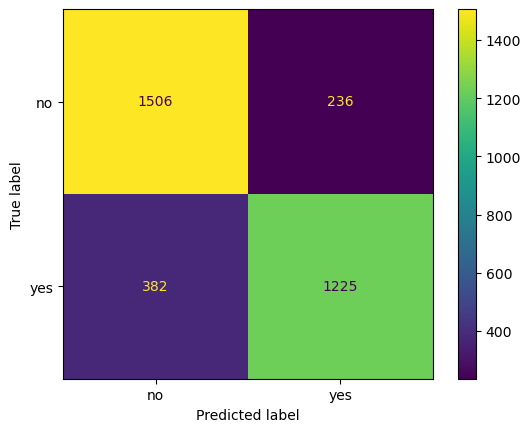

In [81]:
# Confusion matrix

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print(classification_report(y_test, y_pred))

# Fine Tuning

In [82]:
# Parameter for the grid

params = {'max_depth': list(range(6, 13)),
          'min_samples_leaf': list(range(2,9,2)),
          'min_samples_split': list(range(1,5))}

# tuning the model with above combination of parameters

#classifier
dt = DecisionTreeClassifier(random_state=42)

#setup the frid search
grid_search = GridSearchCV(estimator=dt,
                          param_grid=params,
                          cv=5,
                          n_jobs=-1,
                          verbose=4)

#fit the grid search model
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 112 candidates, totalling 560 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [6, 7, 8, 9, 10, 11, 12],
                         'min_samples_leaf': [2, 4, 6, 8],
                         'min_samples_split': [1, 2, 3, 4]},
             verbose=4)

In [83]:
# display the best params and score
print('Best parameters from the grid search are:',grid_search.best_params_)
print('Score for the best params:',round(grid_search.best_score_*100,2))

Best parameters from the grid search are: {'max_depth': 9, 'min_samples_leaf': 6, 'min_samples_split': 2}
Score for the best params: 81.25


In [84]:
# Building the final model with best parameters from the grid search
best_parameters = grid_search.best_params_
final_model = DecisionTreeClassifier(**best_parameters, random_state=42)

#fit the data onto the final model
final_model.fit(x_train, y_train)
print('Training Score:', round(final_model.score(x_train, y_train)*100,2),'%')

Training Score: 85.73 %


In [85]:
#test prediction
y_pred_final = final_model.predict(x_test)

#testing accuracy
final_test_score = accuracy_score(y_test, y_pred_final)
print('Testing Score:',round(final_test_score*100,2),'%')

Testing Score: 80.8 %


              precision    recall  f1-score   support

          no       0.81      0.82      0.82      1742
         yes       0.80      0.79      0.80      1607

    accuracy                           0.81      3349
   macro avg       0.81      0.81      0.81      3349
weighted avg       0.81      0.81      0.81      3349



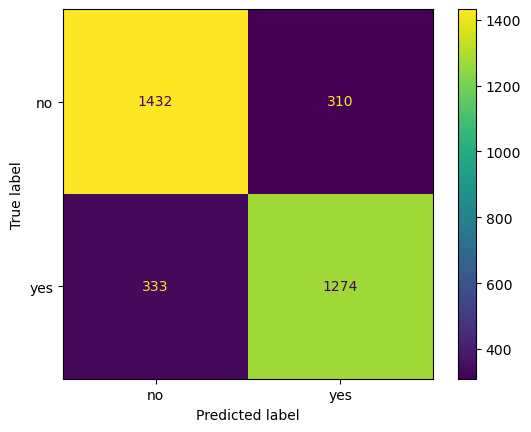

In [86]:
#Detailed Metrics

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print(classification_report(y_test,y_pred_final))

# AUC ROC Curve

In [92]:
# Computing FPR, TPR
y_probs = final_model.predict_proba(x_test)[:,1]
fpr, tpr, thr = roc_curve(y_test, y_probs, pos_label='yes')
auc = roc_auc_score(y_test, y_probs)
print('Area under the curve:',round(auc*100,2),'%')

Area under the curve: 87.58 %


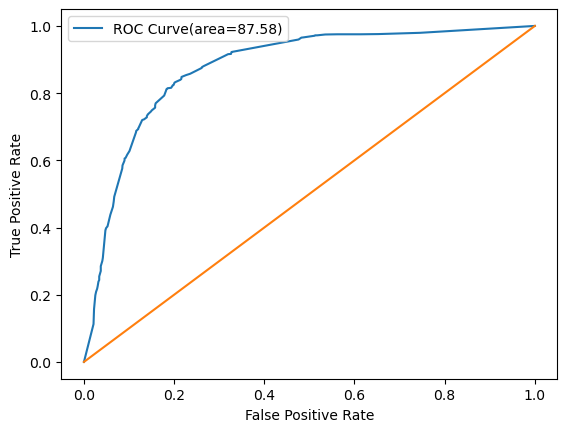

In [93]:
# plotting the auc roc curve

plt.plot(fpr, tpr, label=f'ROC Curve(area={round(auc*100,2)})')
plt.plot([0,1], [0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()